# MP5: Training Your Diffusion Model!

## Setup environment

In [ ]:
# Import essential modules. Feel free to add whatever you need.
import matplotlib.pyplot as plt
import torch # added
from torch import optim # added
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Visualization helper function

In [ ]:
def visualize_images_with_titles(images: torch.Tensor, column_names: list[str]):
    """
    Visualize images as a grid and title the columns with the provided names.

    Args:
        images: (N, C, H, W) tensor of images, where N is (number of rows * number of columns)
        column_names: List of column names for the titles.

    Example usage:
    visualize_images_with_titles(torch.randn(16, 1, 32, 32), ['1', '2', '3', '4'])
    """
    num_images, num_columns = images.shape[0], len(column_names)
    assert num_images % num_columns == 0, 'Number of images must be a multiple of the number of columns.'

    num_rows = num_images // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(num_columns * 1, num_rows * 1))

    for i, ax in enumerate(axes.flat):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if i < num_columns:
            ax.set_title(column_names[i % num_columns])

    plt.tight_layout()
    plt.show()


# Part 1: Training a Single-step Denoising UNet


## Implementing Simple and Composed Ops

In [ ]:
class Conv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.module = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels = out_channels,kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.module(x)


class DownConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.module = nn.Sequential(
          nn.Conv2d(in_channels=in_channels, out_channels = out_channels,kernel_size=3, stride=2, padding=1),
          nn.BatchNorm2d(out_channels),
          nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.module(x)


class UpConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.module = nn.Sequential(
          nn.ConvTranspose2d(in_channels=in_channels, out_channels = out_channels,kernel_size=4, stride=2, padding=1),
          nn.BatchNorm2d(out_channels),
          nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.module(x)


class Flatten(nn.Module):
    def __init__(self):
        super().__init__()
        self.module = nn.AvgPool2d(kernel_size=7)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.module(x)


class Unflatten(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        self.module = nn.Sequential(
          nn.ConvTranspose2d(in_channels=in_channels,out_channels=in_channels, kernel_size=7, stride=7, padding=0),
          nn.BatchNorm2d(in_channels),
          nn.GELU()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.module(x)


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.module = nn.Sequential(
          Conv(in_channels, out_channels),
          Conv(out_channels, out_channels)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.module(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.module = nn.Sequential(
          DownConv(in_channels, out_channels),
          ConvBlock(out_channels, out_channels)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.module(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.module = nn.Sequential(
          UpConv(in_channels, out_channels),
          ConvBlock(out_channels, out_channels)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.module(x)

## Implementing Unconditional UNet

In [ ]:
class UnconditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        super().__init__()
        self.conv1 = ConvBlock(in_channels, num_hiddens)
        self.down1 = DownBlock(num_hiddens, num_hiddens)
        self.down2 = DownBlock(num_hiddens, num_hiddens * 2)
        self.flatten = Flatten()
        self.unflatten = Unflatten(num_hiddens * 2)
        self.up1 = UpBlock(num_hiddens * 4, num_hiddens)
        self.up2 = UpBlock(num_hiddens * 2, num_hiddens)
        self.conv2 = ConvBlock(num_hiddens * 2, num_hiddens)
        self.out = nn.Conv2d(num_hiddens, in_channels,kernel_size = 3, padding = 1,stride = 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."

        layer_1 = self.conv1(x)
        layer_2 = self.down1(layer_1)
        layer_3 = self.down2(layer_2)
        flattened = self.flatten(layer_3)
        unflattened = self.unflatten(flattened)
        layer_3 = torch.cat([unflattened, layer_3], dim = 1)
        layer_3_up = self.up1(layer_3)
        layer_2 = torch.cat([layer_2, layer_3_up], dim = 1)
        layer_2_up = self.up2(layer_2)
        layer_1 = torch.cat([layer_1, layer_2_up], dim = 1)
        layer_1 = self.conv2(layer_1)

        return self.out(layer_1)

## Visualizing the noising process

100%|██████████| 9.91M/9.91M [00:06<00:00, 1.47MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.0MB/s]


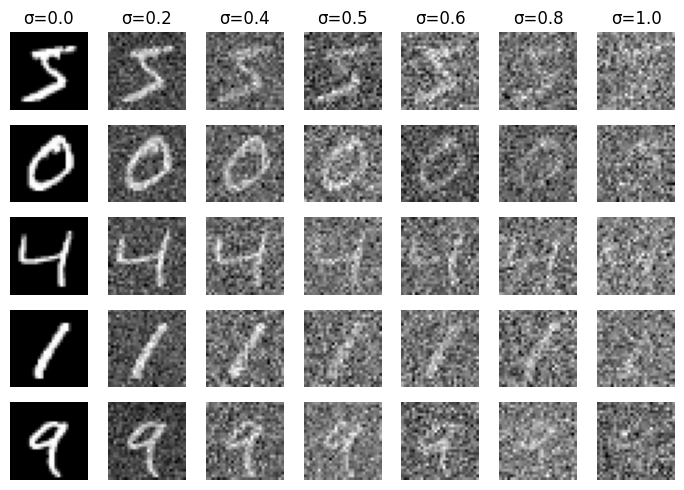

In [ ]:
import torch
from torchvision.datasets import MNIST
from torchvision import transforms

def add_noise(x0, sigma):
    return x0 + torch.randn_like(x0) * sigma

ds = MNIST('.', train=True, download=True, transform=transforms.ToTensor())
samples = torch.stack([ds[i][0] for i in range(5)], dim=0).to(device)

sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

noisy = torch.stack([add_noise(samples, s) for s in sigmas], dim=1)

B, S, C, H, W = noisy.shape
images = noisy.reshape(B * S, C, H, W)

column_names = [f"σ={s:.1f}" for s in sigmas]

visualize_images_with_titles(images, column_names)


## Training a Single-Step Unconditional UNet

- Plot the loss curve
- Sample results on the test set

## Out-of-Distribution Testing

Epoch 1/5 - Avg Loss: 0.0282


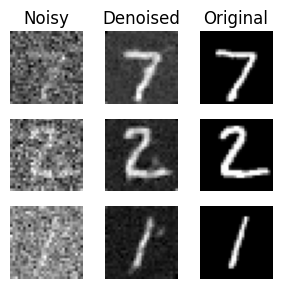

Epoch 2/5 - Avg Loss: 0.0123
Epoch 3/5 - Avg Loss: 0.0102
Epoch 4/5 - Avg Loss: 0.0093
Epoch 5/5 - Avg Loss: 0.0087


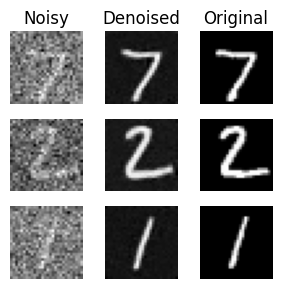

In [ ]:
train_ds = MNIST('.', train=True,  download=True, transform=ToTensor())
test_ds  = MNIST('.', train=False, download=True, transform=ToTensor())
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=True)
test_dl  = DataLoader(test_ds,  batch_size=8,   shuffle=False, drop_last=True)

model = UnconditionalUNet(in_channels=1, num_hiddens=128).to(device)
opt   = torch.optim.Adam(model.parameters(), lr=1e-4)
mse   = nn.MSELoss()
sigma = 0.5

train_losses = []
num_epochs = 5

for epoch in range(1,num_epochs+1):
    model.train()
    tot_loss = 0.0
    for x0, _ in train_dl:
        x0 = x0.to(device)
        x_noisy = x0 + sigma * torch.randn_like(x0)
        pred    = model(x_noisy)
        loss    = mse(pred, x_noisy - x0)
        opt.zero_grad()
        loss.backward()
        opt.step()
        tot_loss += loss.item()
        train_losses.append(loss.item())
    avg_loss = tot_loss / len(train_dl)
    print(f"Epoch {epoch}/{num_epochs} - Avg Loss: {avg_loss:.4f}")

    if epoch in (1, 5):
        model.eval()
        with torch.no_grad():
            x0_test, _ = next(iter(test_dl))
            x0_test = x0_test.to(device)
            x_noisy = x0_test + sigma * torch.randn_like(x0_test)
            pred    = model(x_noisy)
            denoised = x_noisy - pred

            n = 3
            # prepare images in row-major order: [noisy0, denoised0, original0, noisy1, ...]
            imgs = []
            for i in range(n):
                imgs.extend([
                    x_noisy[i:i+1].cpu(),
                    denoised[i:i+1].cpu(),
                    x0_test[i:i+1].cpu()
                ])
            images = torch.cat(imgs, dim=0)  # shape (n*3, 1, 28, 28)
            column_names = ["Noisy", "Denoised", "Original"]
            visualize_images_with_titles(images, column_names)

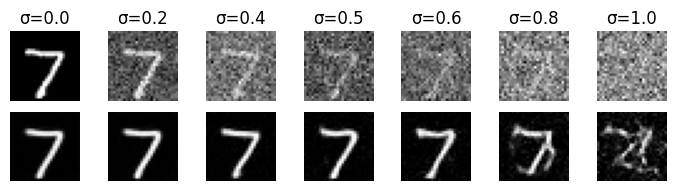

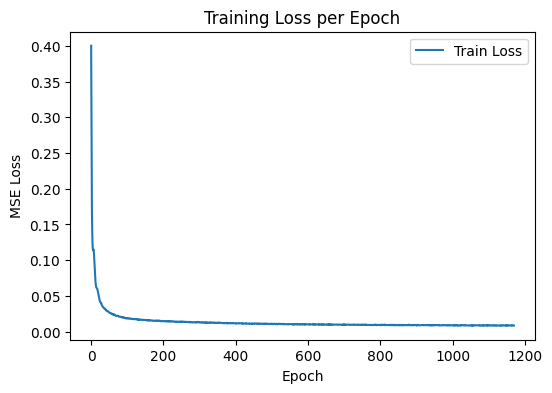

In [ ]:
# TODO

with torch.no_grad():
    test_ds = MNIST('.', train=False, download=True, transform=ToTensor())
    x0, _   = test_ds[0]
    x0      = x0.unsqueeze(0).to(device)
    sigmas  = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

    noisy_imgs    = torch.cat([x0 + s*torch.randn_like(x0) for s in sigmas], dim=0)
    denoised_imgs = torch.cat([(img - model(img)).clamp(0,1) for img in torch.split(noisy_imgs,1)], dim=0)

    images = torch.cat([noisy_imgs, denoised_imgs], dim=0)
    column_names = [f"σ={s:.1f}" for s in sigmas]

    visualize_images_with_titles(images, column_names)

epochs = list(range(1, 6))
plt.figure(figsize=(6,4))
plt.plot(range(0, len(train_losses)), train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss per Epoch')
plt.legend()
plt.show()



# Part 2: Training a Diffusion Model

## Implementing a Time-conditioned UNet

In [ ]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.lin1 = nn.Linear(in_channels, out_channels)
        self.lin2 = nn.Linear(out_channels, out_channels)
        self.gelu = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.type(torch.float32)
        x1 = self.lin1(x)
        x2 = self.gelu(x1)
        return self.lin2(x2)

class TimeConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        self.in_channels = in_channels
        self.num_classes = num_classes
        self.num_hiddens = num_hiddens
        self.conv1 = ConvBlock(in_channels, num_hiddens)
        self.down1 = DownBlock(num_hiddens, num_hiddens)
        self.down2 = DownBlock(num_hiddens, num_hiddens * 2)
        self.flatten = Flatten()
        self.unflatten = Unflatten(num_hiddens * 2)
        self.up1 = UpBlock(num_hiddens * 4, num_hiddens)
        self.up2 = UpBlock(num_hiddens * 2, num_hiddens)
        self.conv2 = ConvBlock(num_hiddens * 2, num_hiddens)
        self.out = nn.Conv2d(num_hiddens, in_channels,kernel_size = 3, padding = 1,stride = 1)
        self.fc1 = FCBlock(1, num_hiddens*2)
        self.fc2 = FCBlock(1, num_hiddens)

    def forward(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        t = t.unsqueeze(-1)  # shape (N, 1)
        layer_1 = self.conv1(x)
        layer_2 = self.down1(layer_1)
        layer_3 = self.down2(layer_2)
        flattened = self.flatten(layer_3)
        t_fc1 = self.fc1(t)
        t_fc1 = t_fc1.view(-1, self.num_hiddens * 2, 1, 1)
        unflattened = t_fc1 * self.unflatten(flattened)
        layer_3 = torch.cat([layer_3, unflattened], dim = -3)
        t_fc2 = self.fc2(t)
        t_fc2 = t_fc2.view(-1, self.num_hiddens, 1, 1)
        layer_3_up = self.up1(layer_3)
        layer_3_up = t_fc2 * layer_3_up
        layer_2 = torch.cat([layer_2, layer_3_up], dim = -3)
        layer_2_up = self.up2(layer_2)
        layer_1 = torch.cat([layer_1, layer_2_up], dim = -3)
        layer_1 = self.conv2(layer_1)

        return self.out(layer_1)

## Implementing DDPM Forward and Inverse Process for Time-conditioned Denoising

In [ ]:
def ddpm_schedule(beta1: float, beta2: float, num_ts: int) -> dict:
    """Constants for DDPM training and sampling.

    Arguments:
        beta1: float, starting beta value.
        beta2: float, ending beta value.
        num_ts: int, number of timesteps.

    Returns:
        dict with keys:
            betas: linear schedule of betas from beta1 to beta2.
            alphas: 1 - betas.
            alpha_bars: cumulative product of alphas.
    """
    assert beta1 < beta2 < 1.0, "Expect beta1 < beta2 < 1.0."
    # YOUR CODE HERE.
    betas = torch.linspace(beta1, beta2, num_ts)
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    return {"betas": betas, "alphas": alphas, "alpha_bars": alpha_bars}


In [ ]:
def ddpm_forward(
    unet: TimeConditionalUNet,
    ddpm_schedule: dict,
    x_0: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1 of the DDPM paper.

    Args:
        unet: TimeConditionalUNet
        ddpm_schedule: dict
        x_0: (N, C, H, W) input tensor.
        num_ts: int, number of timesteps.
    Returns:
        (,) diffusion loss.
    """
    unet.train()

    # YOUR CODE HERE.

    # Algorithm according to paper
    device = x_0.device
    N = x_0.size(0)
    t = torch.randint(0, num_ts, (N,), device=device)
    alpha_bars = ddpm_schedule["alpha_bars"].to(device)
    sqrt_alpha_bar = alpha_bars[t].sqrt().view(N, 1, 1, 1)

    sqrt_one_minus_alpha_bar = (1 - alpha_bars[t]).sqrt().view(N, 1, 1, 1)
    eps = torch.randn_like(x_0)
    x_t = sqrt_alpha_bar * x_0 + sqrt_one_minus_alpha_bar * eps
    t_normalized = t.float() / num_ts
    eps_pred = unet(x_t, t_normalized)
    loss = torch.mean((eps - eps_pred) ** 2)
    return loss

In [ ]:
@torch.inference_mode()
def ddpm_sample(
    unet: TimeConditionalUNet,
    ddpm_schedule: dict,
    img_wh: tuple[int, int],
    num_ts: int,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2 of the DDPM paper.

    Args:
        unet: TimeConditionalUNet
        ddpm_schedule: dict
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
    """
    unet.eval()
    # YOUR CODE HERE.
    torch.manual_seed(seed)
    device = next(unet.parameters()).device
    H, W = img_wh
    x_t = torch.randn((1, unet.in_channels, H, W), device=device)

    betas = ddpm_schedule["betas"].to(device)
    alphas = ddpm_schedule["alphas"].to(device)
    alpha_bars = ddpm_schedule["alpha_bars"].to(device)

    for t in reversed(range(num_ts)):

        # Algorithm according to paper
        ts = torch.full((1,), t, device=device, dtype=torch.long)
        ts_normalized = ts.float() / num_ts
        eps_pred = unet(x_t, ts_normalized)
        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        coef1 = 1 / torch.sqrt(alpha_t)
        coef2 = (1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)
        mean = coef1 * (x_t - coef2 * eps_pred)
        if t > 0:
            sigma_t = torch.sqrt(beta_t)
            noise = torch.randn_like(x_t)
            x_t = mean + sigma_t * noise
        else:
            x_t = mean

    return x_t


In [ ]:
class DDPM(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        betas: tuple[float, float] = (1e-4, 0.02),
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.num_ts = num_ts
        self.p_uncond = p_uncond
        self.ddpm_schedule = ddpm_schedule(betas[0], betas[1], num_ts)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) diffusion loss.
        """
        return ddpm_forward(
            self.unet, self.ddpm_schedule, x, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        img_wh: tuple[int, int],
        seed: int = 0,
    ):
        return ddpm_sample(
            self.unet, self.ddpm_schedule, img_wh, self.num_ts, seed
        )

## Training the Time-conditioned UNet

- Plot the loss curve
- Sample results on the test set

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.56MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 58.6kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.05MB/s]


Epoch 1/20 - Avg Loss: 0.0708
Epoch 2/20 - Avg Loss: 0.0427
Epoch 3/20 - Avg Loss: 0.0369
Epoch 4/20 - Avg Loss: 0.0344
Epoch 5/20 - Avg Loss: 0.0328


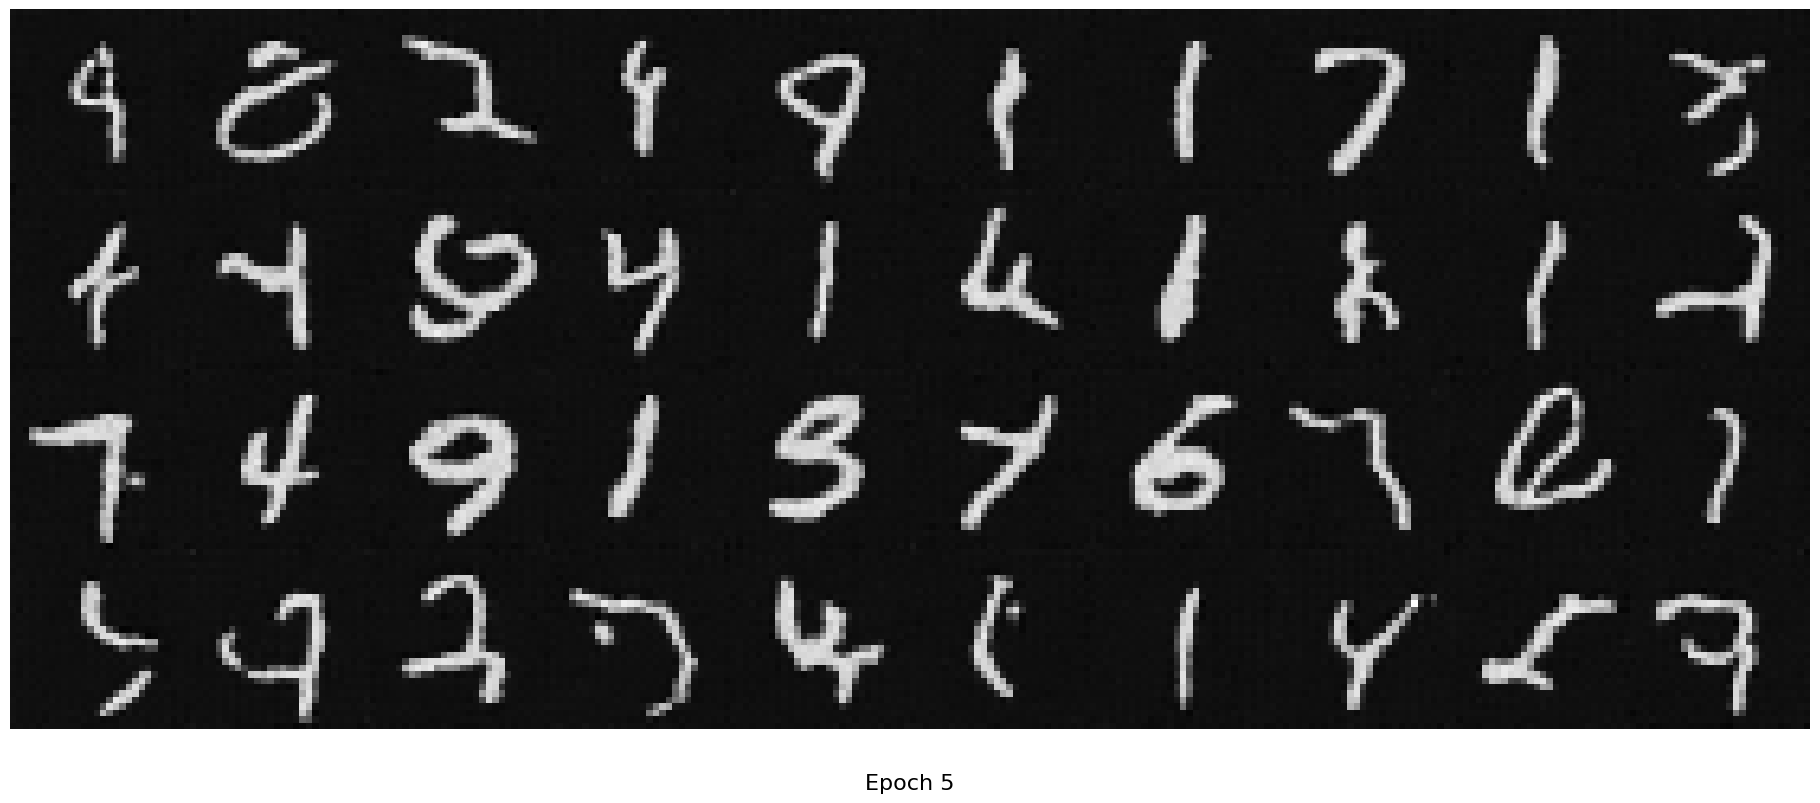

Epoch 6/20 - Avg Loss: 0.0314
Epoch 7/20 - Avg Loss: 0.0309
Epoch 8/20 - Avg Loss: 0.0306
Epoch 9/20 - Avg Loss: 0.0300
Epoch 10/20 - Avg Loss: 0.0297
Epoch 11/20 - Avg Loss: 0.0294
Epoch 12/20 - Avg Loss: 0.0290
Epoch 13/20 - Avg Loss: 0.0289
Epoch 14/20 - Avg Loss: 0.0285
Epoch 15/20 - Avg Loss: 0.0283
Epoch 16/20 - Avg Loss: 0.0283
Epoch 17/20 - Avg Loss: 0.0282
Epoch 18/20 - Avg Loss: 0.0280
Epoch 19/20 - Avg Loss: 0.0279
Epoch 20/20 - Avg Loss: 0.0277


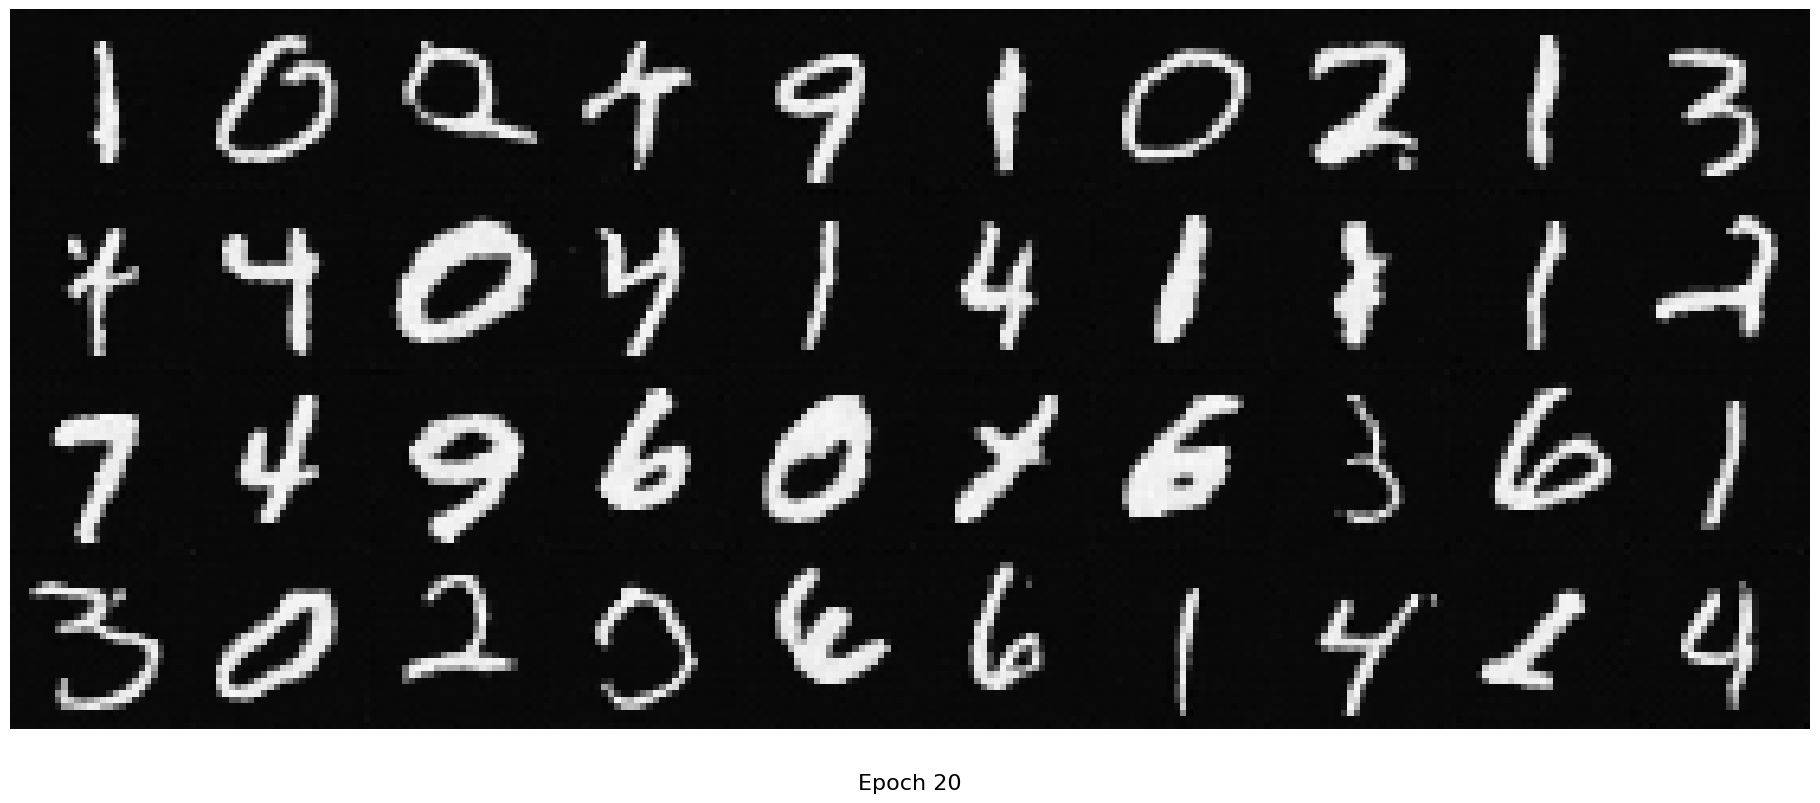

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import torchvision

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dataset = MNIST(root='data', download=True, transform=ToTensor(), train=True)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)

unet = TimeConditionalUNet(in_channels=1, num_classes=10, num_hiddens=64)
num_epochs = 20
model = DDPM(unet=unet, betas=(1e-4, 0.02), num_ts=300).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ExponentialLR(
    optimizer, gamma=0.1**(0.1/num_epochs)
)

train_losses = []
samples_epoch_5 = None
samples_epoch_20 = None

for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss = 0.0
    for x0, _ in dataloader:
        x0 = x0.to(device)
        loss = model(x0)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        train_losses.append(loss.item())
    scheduler.step()
    avg_loss = total_loss / len(dataloader)

    print(f"Epoch {epoch}/{num_epochs} - Avg Loss: {avg_loss:.4f}")

    if epoch in [5, 20]:
        model.eval()
        with torch.no_grad():
            samples = []

            for i in range(40):
                traj = model.sample(img_wh=(28, 28), seed=i)
                final = traj[-1]
                samples.append(final.cpu())
            samples = torch.stack(samples, dim=0)

        grid = torchvision.utils.make_grid(
            samples,
            nrow=10,
            normalize=True,
            padding=0
        )

        fig = plt.figure(figsize=(20, 8))
        plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
        plt.axis('off')

        plt.subplots_adjust(left=0, right=1, top=1, bottom=0.1)
        fig.text(0.5, 0.02, f"Epoch {epoch}", ha='center', va='bottom', fontsize=16)
        plt.show()


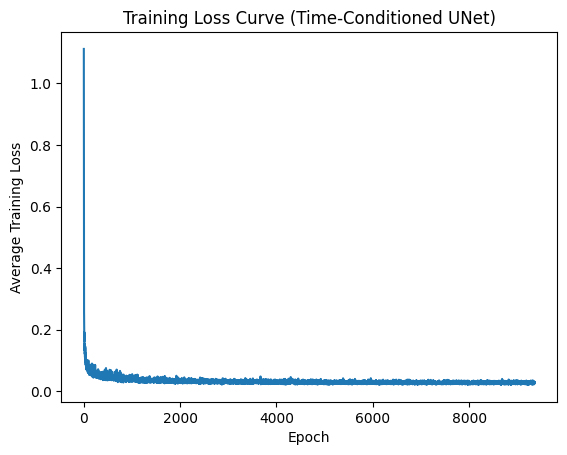

In [ ]:
# Figure 10: Training loss curve
plt.figure()
plt.plot(list(range(1, len(train_losses) + 1)), train_losses)
plt.xlabel('Epoch')
plt.ylabel('Average Training Loss')
plt.title('Training Loss Curve (Time-Conditioned UNet)')
plt.show()


### Implementing class-conditioned UNet

In [ ]:
class ClassConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        self.in_channels = in_channels
        self.num_classes = num_classes
        self.num_hiddens = num_hiddens

        # main UNet backbone (same as time-only)
        self.conv1 = ConvBlock(in_channels, num_hiddens)
        self.down1 = DownBlock(num_hiddens, num_hiddens)
        self.down2 = DownBlock(num_hiddens, num_hiddens * 2)
        self.flatten = Flatten()
        self.unflatten = Unflatten(num_hiddens * 2)
        self.up1 = UpBlock(num_hiddens * 4, num_hiddens)
        self.up2 = UpBlock(num_hiddens * 2, num_hiddens)
        self.conv2 = ConvBlock(num_hiddens * 2, num_hiddens)
        self.out = nn.Conv2d(num_hiddens, in_channels, kernel_size=3, padding=1, stride=1)

        # time and class embeddings
        self.fc1_t = FCBlock(1, num_hiddens * 2)
        self.fc2_t = FCBlock(1, num_hiddens)
        self.fc1_c = FCBlock(num_classes, num_hiddens * 2)
        self.fc2_c = FCBlock(num_classes, num_hiddens)

    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."

        N = x.shape[0]
        t = t.unsqueeze(-1)

        # one-hot encode class
        c_onehot = F.one_hot(c, num_classes=self.num_classes).float()

        # apply mask if provided (for classifier-free guidance)
        if mask is not None:
            c_onehot = c_onehot * mask.unsqueeze(-1)

        t_fc1 = self.fc1_t(t)
        t_fc2 = self.fc2_t(t)
        c_fc1 = self.fc1_c(c_onehot)
        c_fc2 = self.fc2_c(c_onehot)
        layer_1 = self.conv1(x)
        layer_2 = self.down1(layer_1)
        layer_3 = self.down2(layer_2)
        flattened = self.flatten(layer_3)
        t_fc1 = t_fc1.view(N, self.num_hiddens * 2, 1, 1)
        c_fc1 = c_fc1.view(N, self.num_hiddens * 2, 1, 1)
        unflattened = (1 + c_fc1) * self.unflatten(flattened) + t_fc1
        layer_3 = torch.cat([layer_3, unflattened], dim=1)
        layer_3_up = self.up1(layer_3)
        t_fc2 = t_fc2.view(N, self.num_hiddens, 1, 1)
        c_fc2 = c_fc2.view(N, self.num_hiddens, 1, 1)
        layer_3_up = (1 + c_fc2) * layer_3_up + t_fc2
        layer_2 = torch.cat([layer_2, layer_3_up], dim=1)
        layer_2_up = self.up2(layer_2)
        layer_1 = torch.cat([layer_1, layer_2_up], dim=1)
        layer_1 = self.conv2(layer_1)

        return self.out(layer_1)


In [ ]:
def ddpm_forward(
    unet: ClassConditionalUNet,
    ddpm_schedule: dict,
    x_0: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1 of the DDPM paper.

    Args:
        unet: ClassConditionalUNet
        ddpm_schedule: dict
        x_0: (N, C, H, W) input tensor.
        c: (N,) int64 condition tensor.
        p_uncond: float, probability of unconditioning the condition.
        num_ts: int, number of timesteps.

    Returns:
        (,) diffusion loss.
    """
    unet.train()

    # YOUR CODE HERE.
    # As per Algorithm in paper
    device = x_0.device
    N = x_0.size(0)

    t = torch.randint(0, num_ts, (N,), device=device)

    alpha_bars = ddpm_schedule["alpha_bars"].to(device)
    sqrt_alpha_bar = alpha_bars[t].sqrt().view(N, 1, 1, 1)
    sqrt_one_minus_alpha_bar = (1 - alpha_bars[t]).sqrt().view(N, 1, 1, 1)

    noise = torch.randn_like(x_0)
    x_t = sqrt_alpha_bar * x_0 + sqrt_one_minus_alpha_bar * noise
    t_normalized = t.float() / num_ts
    mask = (torch.rand(N, device=device) > p_uncond).float()
    pred_noise = unet(x_t, c, t_normalized, mask)
    loss = F.mse_loss(pred_noise, noise)

    return loss


In [ ]:
@torch.inference_mode()
def ddpm_sample(
    unet: ClassConditionalUNet,
    ddpm_schedule: dict,
    c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2 of the DDPM paper with classifier-free guidance.

    Args:
        unet: ClassConditionalUNet
        ddpm_schedule: dict
        c: (N,) int64 condition tensor. Only for class-conditional
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        guidance_scale: float, CFG scale.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
        (N, T_animation, C, H, W) caches.
    """
    unet.eval()
    # YOUR CODE HERE.

    torch.manual_seed(seed)
    device = next(unet.parameters()).device

    N = c.shape[0]
    C = unet.in_channels
    H, W = img_wh
    x_t = torch.randn((N, C, H, W), device=device)
    betas = ddpm_schedule["betas"].to(device)
    alphas = ddpm_schedule["alphas"].to(device)
    alpha_bars = ddpm_schedule["alpha_bars"].to(device)
    caches = []

    # As per Algorithm in paper

    for t in reversed(range(num_ts)):
        ts = torch.full((N,), t, device=device, dtype=torch.long)
        t_normalized = ts.float() / num_ts
        mask_uncond = torch.zeros_like(ts, dtype=torch.float32)
        eps_uncond = unet(x_t, c, t_normalized, mask_uncond)
        mask_cond = torch.ones_like(ts, dtype=torch.float32)
        eps_cond = unet(x_t, c, t_normalized, mask_cond)

        # Apply classifier-free guidance
        eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        coef1 = 1 / torch.sqrt(alpha_t)
        coef2 = (1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)
        mean = coef1 * (x_t - coef2 * eps)
        if t > 0:
            sigma_t = torch.sqrt(beta_t)
            noise = torch.randn_like(x_t)
            x_t = mean + sigma_t * noise
        else:
            x_t = mean
        caches.append(x_t.clone())
    caches = torch.stack(caches, dim=0).permute(1, 0, 2, 3, 4)

    return x_t, caches


In [ ]:
class DDPM(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        betas: tuple[float, float] = (1e-4, 0.02),
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.betas = betas
        self.num_ts = num_ts
        self.p_uncond = p_uncond
        self.ddpm_schedule = ddpm_schedule(betas[0], betas[1], num_ts)

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) diffusion loss.
        """
        return ddpm_forward(
            self.unet, self.ddpm_schedule, x, c, self.p_uncond, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        c: torch.Tensor,
        img_wh: tuple[int, int],
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return ddpm_sample(
            self.unet, self.ddpm_schedule, c, img_wh, self.num_ts, guidance_scale, seed
        )

## Training the Class-conditioned UNet

- Plot the loss curve
- Sample results on the test set

Epoch 1/20 - Avg Loss: 0.0646
Epoch 2/20 - Avg Loss: 0.0409
Epoch 3/20 - Avg Loss: 0.0359
Epoch 4/20 - Avg Loss: 0.0336
Epoch 5/20 - Avg Loss: 0.0313


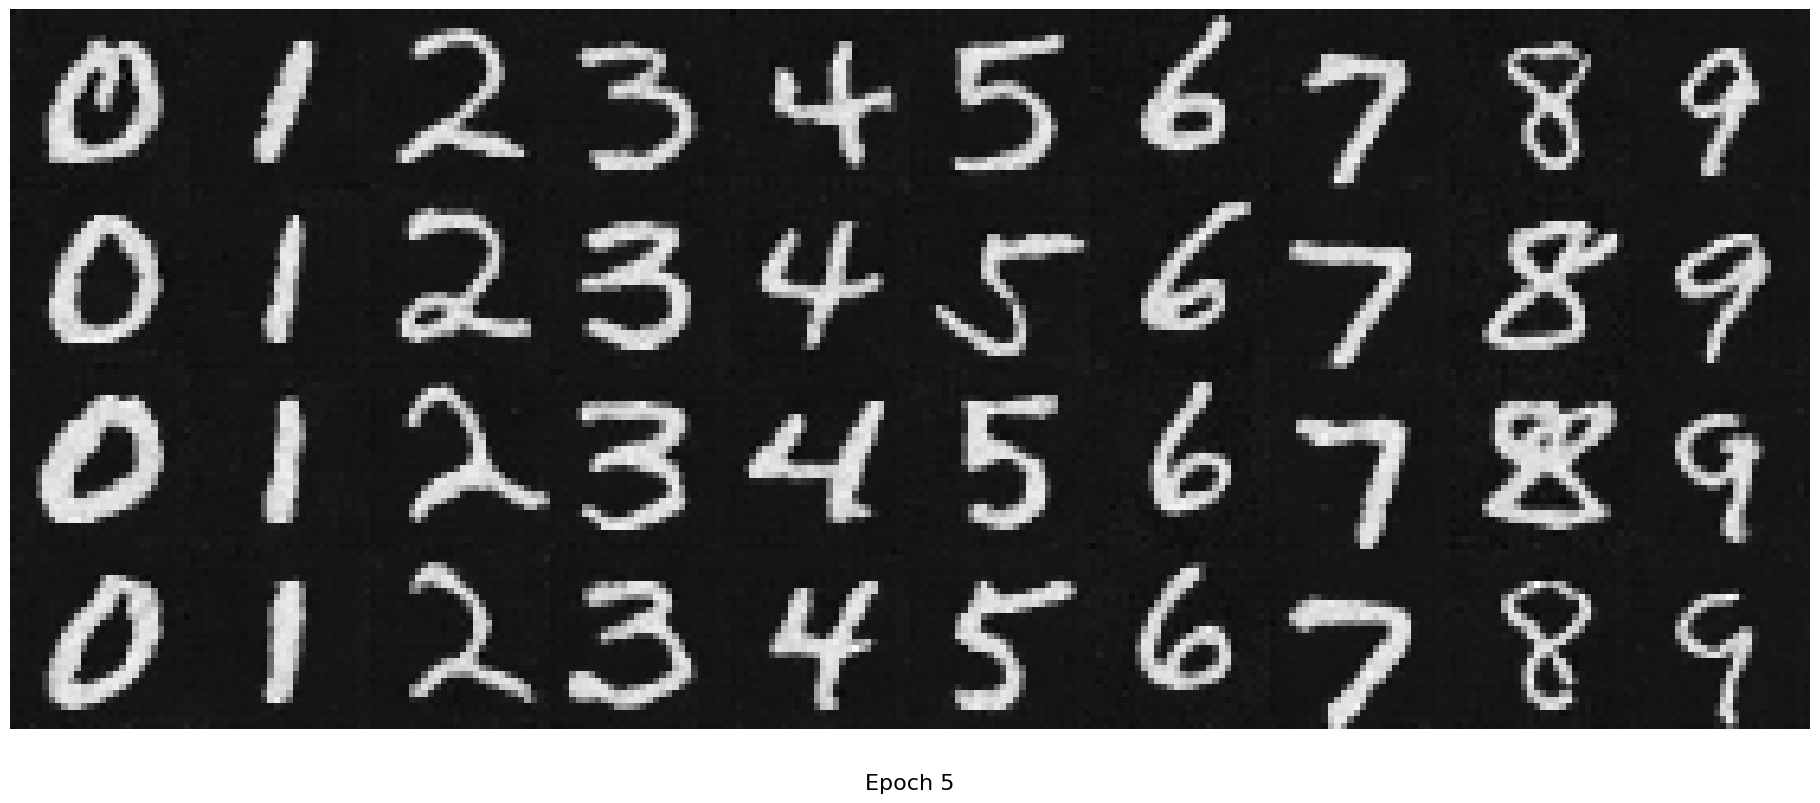

Epoch 6/20 - Avg Loss: 0.0310
Epoch 7/20 - Avg Loss: 0.0299
Epoch 8/20 - Avg Loss: 0.0295
Epoch 9/20 - Avg Loss: 0.0291
Epoch 10/20 - Avg Loss: 0.0287
Epoch 11/20 - Avg Loss: 0.0283
Epoch 12/20 - Avg Loss: 0.0283
Epoch 13/20 - Avg Loss: 0.0278
Epoch 14/20 - Avg Loss: 0.0276
Epoch 15/20 - Avg Loss: 0.0270
Epoch 16/20 - Avg Loss: 0.0273
Epoch 17/20 - Avg Loss: 0.0270
Epoch 18/20 - Avg Loss: 0.0265
Epoch 19/20 - Avg Loss: 0.0267
Epoch 20/20 - Avg Loss: 0.0267


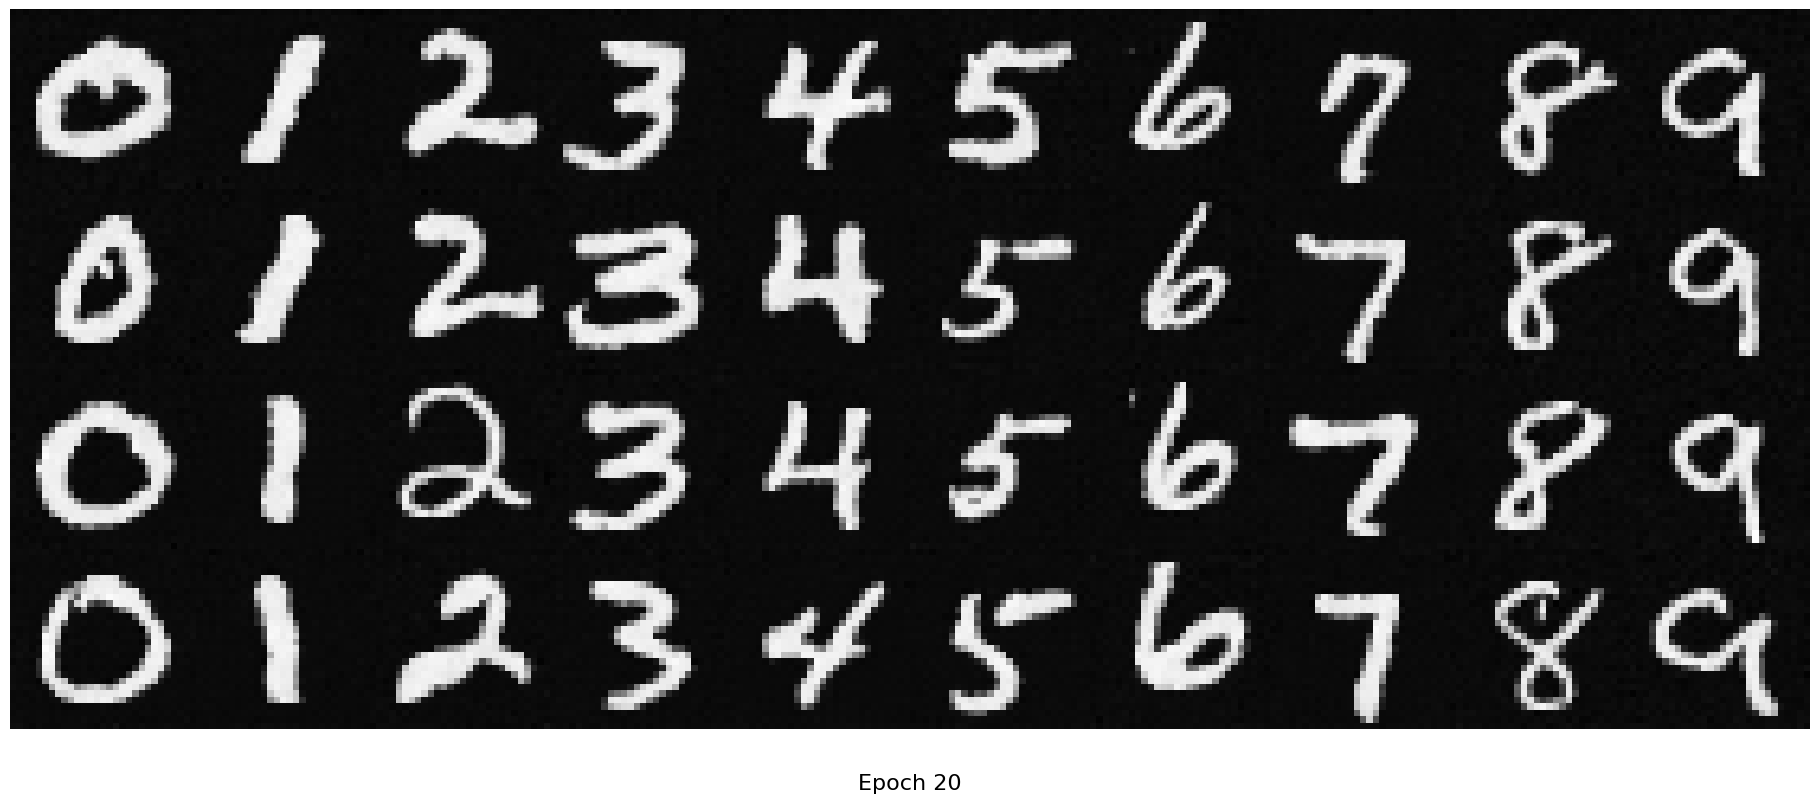

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
import torchvision
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dataset = MNIST(root='data', download=True, transform=ToTensor(), train=True)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

unet = ClassConditionalUNet(in_channels=1, num_classes=10, num_hiddens=64).to(device)
model = DDPM(unet=unet, betas=(1e-4, 0.02), num_ts=300, p_uncond=0.1).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ExponentialLR(
    optimizer, gamma=0.1**(0.1/20)
)

num_epochs = 20
train_losses = []

for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss = 0.0

    for x0, labels in dataloader:
        x0, labels = x0.to(device), labels.to(device)
        loss = model(x0, labels)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        train_losses.append(loss.item())

    scheduler.step()
    print(f"Epoch {epoch}/{num_epochs} - Avg Loss: {total_loss/len(dataloader):.4f}")

    if epoch in [5, 20]:
        model.eval()
        with torch.no_grad():

            c = torch.arange(0, 10, device=device).repeat(4)
            samples, _ = model.sample(
                c,
                img_wh=(28, 28),
                guidance_scale=5.0,
                seed=epoch
            )
            samples = samples.cpu()
        grid = torchvision.utils.make_grid(
            samples,
            nrow=10,
            normalize=True,
            padding=0
        )

        fig = plt.figure(figsize=(20, 8))
        plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
        plt.axis('off')

        plt.subplots_adjust(left=0, right=1, top=1, bottom=0.1)
        fig.text(0.5, 0.02, f"Epoch {epoch}", ha='center', va='bottom', fontsize=16)
        plt.show()


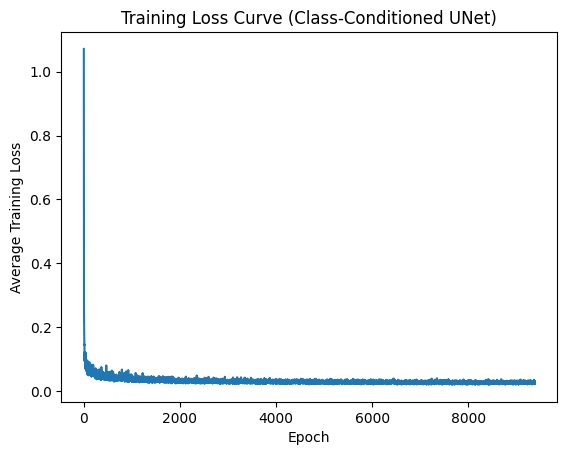

In [ ]:
# Plot training loss
plt.figure()
plt.plot(range(1, len(train_losses) + 1), train_losses)
plt.xlabel('Epoch')
plt.ylabel('Average Training Loss')
plt.title('Training Loss Curve (Class-Conditioned UNet)')
plt.show()
